# 03 — Evaluation & Model Comparison
Load trained models, run held-out evaluation, and compare
Random Forest vs. MLP vs. LSTM vs. Hybrid on all metrics.


## 1. Imports & setup

In [1]:
import sys, pathlib, shutil, json
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from library.utils           import setup_logging, get_device
from library.config          import BatchConfig
from library.data.registry   import load_registry_manifest  # A1/A2: load, don't recompute
from library.data.loader     import load_split  # canonical, memory-bounded loader
from library.features        import build_feature_matrix
from library.models.dataset  import build_memmap_arrays, WindowDataset
from library.models.trainer  import evaluate_model
from library.visualization   import (plot_confusion, plot_per_fault_f1,
                                     plot_cross_location, plot_ablation)
from sklearn.metrics import roc_auc_score, classification_report
from torch.utils.data import DataLoader

setup_logging()
%matplotlib inline
plt.rcParams["figure.dpi"] = 120


## 2. Paths

In [2]:
PT_DIR      = "outputs/sequence_models"
OUTPUT_DIR  = "outputs/evaluation"
# A1 fix: load the manifest that notebook 02 persisted — never re-run
# prepare_file_registry() or assign_splits() here. The manifest contains
# the exact split assignment from training so there is no drift.
MANIFEST_PATH = f"{PT_DIR}/registry_manifest.json"
pathlib.Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

cfg    = BatchConfig("dataset")
device = get_device()


  Config: array=5.34 kWp, 9 location(s) from batch_config.json
  Simulation-only columns found in data and excluded from all feature sets: ['detailed_balance_efficiency_pct'] (theoretical-only), ['ac_wiring_loss_factor', 'aging_factor', 'aoi_correction_factor', 'availability_factor', 'bifacial_gain', 'dc_wiring_loss_factor', 'inverter_derating_factor', 'inverter_efficiency', 'inverter_loss_kw', 'lid_factor', 'mismatch_loss_factor', 'shading_factor', 'snow_loss_factor', 'soiling_factor', 'spectral_factor', 'vulnerability'] (simulator-internal — never a training input, even for "full")
  Columns: 11 SCADA, 6 IV-curve, 5 stress, 38 constant (excluded), 17 simulation-only (excluded), 0 uncategorized (excluded), 22 total features
Device: GPU — NVIDIA GeForce RTX 4090


## 3. Load evaluation data

In [3]:
# A1 fix: load the already-split registry from the manifest written by
# notebook 02. No MAX_RUNS, no assign_splits(), no possibility of drift.
registry, model_paths = load_registry_manifest(MANIFEST_PATH)

# Bug 6 fix: load scaler and label-encoder paths persisted by nb02 instead of
# reconstructing them from hardcoded naming conventions that break when
# artifact_prefix is non-default.
_extra        = json.loads(pathlib.Path(MANIFEST_PATH).read_text()).get("extra", {})
_scaler_paths = _extra.get("scaler_paths", {})
_le_paths     = _extra.get("le_paths", {})

test_entries     = [e for e in registry if e.get("split") == "test"]
test_entries_cls = [e for e in test_entries if e["fault_type"] != "none"]
print(f"Test set: {len(test_entries)} files total, "
      f"{len(test_entries_cls)} with fault labels")
vc = {}
for e in test_entries:
    vc[e["fault_type"]] = vc.get(e["fault_type"], 0) + 1
for ft, cnt in sorted(vc.items()):
    print(f"  {ft}: {cnt} file(s)")

print("\nModel paths from manifest (A2 fix):")
for task, paths in model_paths.items():
    for mode, p in paths.items():
        print(f"  [{task}] {mode}: {p}")


Loaded registry manifest: outputs/sequence_models/registry_manifest.json  (418 files: test=79, train=260, val=79)
Test set: 79 files total, 74 with fault labels
  bypass_diode_short: 6 file(s)
  cell_crack: 5 file(s)
  combo: 5 file(s)
  connector_burnout: 8 file(s)
  curtailment: 5 file(s)
  mppt_failure: 5 file(s)
  none: 5 file(s)
  pid: 12 file(s)
  sensor_drift: 7 file(s)
  solder_fatigue: 11 file(s)
  string_failure: 5 file(s)
  sudden_soiling: 5 file(s)

Model paths from manifest (A2 fix):
  [fault_active] random_forest: outputs/sequence_models/model_fault_detection_random_forest.pkl
  [fault_active] mlp: outputs/sequence_models/model_fault_detection_mlp.pt
  [fault_active] lstm: outputs/sequence_models/model_fault_detection_lstm.pt
  [fault_active] hybrid: outputs/sequence_models/model_fault_detection_hybrid.pt
  [fault_type] random_forest: outputs/sequence_models/model_fault_classification_random_forest.pkl
  [fault_type] mlp: outputs/sequence_models/model_fault_classification

## 4. Evaluate Random Forest models

In [4]:
import joblib

# Cap eval-set rows the same way training caps them (trainer.py's
# max_test_rows default). Previously this cell hand-rolled its own
# loader (pd.read_parquet + add_features per file, looped and
# concatenated with no cap at all) instead of going through the
# library's canonical load_split — bypassing both its memory-bounded
# incremental subsampling and its sim_year_filter handling, and fully
# materializing every test file in memory regardless of how many there
# were. That was the same crash-causing pattern as notebook 02's
# tabular training path, reimplemented independently here.
MAX_EVAL_ROWS = 1_000_000

def eval_tabular_model(pkl_path, entries, task="detection"):
    """Evaluate any saved tabular model (RF, LightGBM, LR, EBM …) on the registry test files."""
    artifact = joblib.load(pkl_path)
    model    = artifact["model"]
    feats    = artifact["feature_names"]

    # load_split reuses load_registry_entry under the hood — identical
    # daytime filter + feature engineering + sim_year_filter handling as
    # training used, and bounds peak memory to ~MAX_EVAL_ROWS instead of
    # the full test-split size.
    test_df = load_split(entries, cfg, max_rows=MAX_EVAL_ROWS)
    if task == "classification" and "fault_active" in test_df.columns:
        test_df = test_df[test_df["fault_active"]].copy()

    if test_df.empty:
        print("  No rows loaded for this entry set — skipping")
        return None, None, None

    X, _ = build_feature_matrix(test_df, feats)

    if task == "detection":
        y      = test_df["fault_active"].values.astype(int)
        y_prob = model.predict_proba(X)[:, 1]
        y_pred = model.predict(X)
        auc    = roc_auc_score(y, y_prob)
        print(f"  AUC = {auc:.4f}")
        print(classification_report(y, y_pred, target_names=["Healthy", "Faulted"]))
        return auc, y, y_pred
    else:
        le = artifact["label_encoder"]
        # Bug 5 fix: filter out fault types not seen during training before
        # calling le.transform — any unseen type raises a ValueError.
        known = test_df["fault_type"].isin(le.classes_)
        n_dropped = int((~known).sum())
        if n_dropped:
            print(f"  Dropped {n_dropped} rows with unseen fault types")
        test_df = test_df.loc[known].copy()
        if test_df.empty:
            print("  No rows with known fault types — skipping")
            return None, None, None
        X, _ = build_feature_matrix(test_df, feats)  # recompute after filter
        y      = le.transform(test_df["fault_type"].values)
        y_prob = model.predict_proba(X)
        y_pred = model.predict(X)
        auc    = roc_auc_score(y, y_prob, multi_class="ovr", average="weighted")
        print(f"  Weighted OvR AUC = {auc:.4f}")
        print(classification_report(le.inverse_transform(y), le.inverse_transform(y_pred)))
        return auc, le.inverse_transform(y), le.inverse_transform(y_pred)

# A2 fix: look up model paths from the manifest — no hardcoded directory/filename conventions.
# Every tabular mode (RF, LightGBM, LR, EBM, …) is handled the same way.
results_summary = {}

for mode, pkl_path_str in model_paths.get("fault_active", {}).items():
    if pkl_path_str is None or not pkl_path_str.endswith(".pkl"):
        continue   # sequence-model .pt files are handled in cell 11
    pkl_path = pathlib.Path(pkl_path_str)
    if not pkl_path.exists():
        print(f"  [{mode}] model not found: {pkl_path} — skipping")
        continue
    print(f"\n{mode.upper()} Detection (registry test split):")
    try:
        auc, y_t, y_p = eval_tabular_model(pkl_path, test_entries, "detection")
        results_summary[f"{mode.upper()} Detection AUC"] = auc
        plot_confusion(y_t, y_p, ["Healthy", "Faulted"],
                       f"{mode.upper()} Detection",
                       f"{OUTPUT_DIR}/confusion_{mode}_detection.png")
    except Exception as ex:
        print(f"  (skipped: {ex})")



RANDOM_FOREST Detection (registry test split):
After daytime filter: 307,611 rows
After daytime filter: 308,092 rows
After daytime filter: 307,730 rows
After daytime filter: 306,893 rows
After daytime filter: 307,731 rows
After daytime filter: 307,362 rows
After daytime filter: 304,076 rows
After daytime filter: 306,872 rows
After daytime filter: 306,362 rows
After daytime filter: 303,910 rows
  Stratified subsample (by fault_type) → 1,000,000 rows
  load_split: shrank buffer to 1,000,000 rows after 10/79 entries
After daytime filter: 305,312 rows
After daytime filter: 306,643 rows
After daytime filter: 306,438 rows
After daytime filter: 302,403 rows
After daytime filter: 306,472 rows
After daytime filter: 305,936 rows
After daytime filter: 306,525 rows
  Stratified subsample (by fault_type) → 1,000,000 rows
  load_split: shrank buffer to 1,000,000 rows after 17/79 entries
After daytime filter: 306,950 rows
After daytime filter: 298,935 rows
After daytime filter: 302,316 rows
After da

In [5]:
for mode, pkl_path_str in model_paths.get("fault_type", {}).items():
    if pkl_path_str is None or not pkl_path_str.endswith(".pkl"):
        continue
    pkl_path = pathlib.Path(pkl_path_str)
    if not pkl_path.exists():
        print(f"  [{mode}] model not found: {pkl_path} — skipping")
        continue
    print(f"\n{mode.upper()} Classification (registry test split):")
    try:
        auc, y_t, y_p = eval_tabular_model(pkl_path, test_entries_cls, "classification")
        results_summary[f"{mode.upper()} Classification AUC"] = auc
    except Exception as ex:
        print(f"  (skipped: {ex})")



RANDOM_FOREST Classification (registry test split):
After daytime filter: 306,843 rows
After daytime filter: 306,472 rows
After daytime filter: 308,122 rows
After daytime filter: 306,861 rows
After daytime filter: 306,643 rows
After daytime filter: 306,790 rows
After daytime filter: 304,181 rows
After daytime filter: 302,527 rows
After daytime filter: 304,167 rows
After daytime filter: 306,812 rows
  Stratified subsample (by fault_type) → 1,000,000 rows
  load_split: shrank buffer to 1,000,000 rows after 10/74 entries
After daytime filter: 306,872 rows
After daytime filter: 302,410 rows
After daytime filter: 304,147 rows
After daytime filter: 305,266 rows
After daytime filter: 304,076 rows
After daytime filter: 307,194 rows
After daytime filter: 306,683 rows
  Stratified subsample (by fault_type) → 1,000,000 rows
  load_split: shrank buffer to 1,000,000 rows after 17/74 entries
After daytime filter: 298,935 rows
After daytime filter: 302,091 rows
After daytime filter: 305,719 rows
Aft

## 5. Evaluate PyTorch models

In [6]:
import torch
import joblib
# neural_network.py has been removed — build_model now lives in
# definitions.py as a single mode-first factory shared by every model
# family (tabular and sequence). Note the argument order change below:
# mode is now the first positional arg, n_features/n_classes are kwargs.
from library.models.definitions import build_model

def eval_pytorch_model(pt_path, registry, task="detection"):
    """Evaluate a saved PyTorch checkpoint using real temporal windows.

    Loads the training scaler from disk (same one used during training),
    builds memmap arrays from registry test files, and runs the model
    through WindowDataset — the same path used at training time.
    This replaces the previous broken approach that constructed fake windows
    by repeating a single timestep, which destroyed LSTM temporal modeling.
    """
    checkpoint  = torch.load(pt_path, map_location=device, weights_only=False)
    mode        = checkpoint["mode"]
    n_features  = checkpoint["n_features"]
    n_classes   = checkpoint["n_classes"]
    class_names = checkpoint["class_names"]
    feat_names  = checkpoint["feature_names"]
    window_size = checkpoint["window_size"]
    stride      = checkpoint.get("stride", 24)   # fallback for old checkpoints

    model = build_model(
        mode, n_features=n_features, n_classes=n_classes,
        hidden_lstm=checkpoint["hidden_lstm"],
        hidden_mlp=checkpoint["hidden_mlp"],
        n_lstm_layers=checkpoint["n_lstm_layers"],
        dropout=checkpoint["dropout"],
    )
    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)
    model.eval()

    is_cls     = (task == "classification")
    target_col = "fault_type" if is_cls else "fault_active"
    task_key   = "fault_type" if is_cls else "fault_active"

    # Bug 6 fix: derive scaler / LE paths from manifest extras persisted by
    # nb02, not from a hardcoded naming convention that breaks when
    # artifact_prefix is non-default.
    scaler_path_str = _scaler_paths.get(task_key)
    if scaler_path_str is None:
        # Fallback to conventional name if manifest pre-dates the fix
        scaler_tag  = "fault_classification" if is_cls else "fault_detection"
        scaler_path_str = str(pathlib.Path(PT_DIR) / f"scaler_{scaler_tag}.pkl")
        print(f"  [fallback] scaler path not in manifest — trying: {scaler_path_str}")
    scaler_path = pathlib.Path(scaler_path_str)
    if not scaler_path.exists():
        print(f"  Scaler not found: {scaler_path} — skipping.")
        return None, None, None, class_names
    scaler = joblib.load(scaler_path)

    le = None
    if is_cls:
        le_path_str = _le_paths.get("fault_type")
        if le_path_str is None:
            le_path_str = str(pathlib.Path(PT_DIR) / "label_encoder_fault_classification.pkl")
            print(f"  [fallback] LE path not in manifest — trying: {le_path_str}")
        le_path = pathlib.Path(le_path_str)
        if not le_path.exists():
            print(f"  Label encoder not found — skipping.")
            return None, None, None, class_names
        le = joblib.load(le_path)

    test_e = [e for e in registry if e.get("split") == "test"]
    if is_cls:
        test_e = [e for e in test_e if e["fault_type"] != "none"]

    test_runs, cache_dir = build_memmap_arrays(
        test_e, feat_names, target_col, cfg, scaler, le,
        faulted_only=is_cls,
    )

    test_ds     = WindowDataset(test_runs, window_size, stride)
    test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)

    if len(test_ds) == 0:
        print("  No windows in test set — try smaller window_size.")
        shutil.rmtree(cache_dir, ignore_errors=True)
        return None, None, None, class_names

    y_true, y_pred, y_prob, report, auc = evaluate_model(
        model, test_loader, device, class_names=class_names,
    )

    shutil.rmtree(cache_dir, ignore_errors=True)
    return auc, y_true, y_pred, class_names

# A2 fix: dispatch PyTorch models the same way as tabular — from manifest paths,
# no special-casing of .pt vs .pkl. Both detection and classification in one loop.
for task_col, task_label, task_str, entries in [
    ("fault_active", "Detection",      "detection",      test_entries),
    ("fault_type",   "Classification",  "classification", test_entries_cls),
]:
    for mode, pt_path_str in model_paths.get(task_col, {}).items():
        if pt_path_str is None or not pt_path_str.endswith(".pt"):
            continue   # tabular .pkl files already handled in cells 8/9
        pt_path = pathlib.Path(pt_path_str)
        if not pt_path.exists():
            print(f"  [{mode}] model not found: {pt_path} — skipping")
            continue
        print(f"\nPyTorch {mode.upper()} — {task_label}")
        try:
            auc, y_t, y_p, cnames = eval_pytorch_model(pt_path, registry, task_str)
            if auc is not None:
                results_summary[f"PT {mode.upper()} {task_label} AUC"] = auc
        except Exception as ex:
            print(f"  (skipped: {ex})")



PyTorch MLP — Detection
  Built model: mode=mlp  params=10,562
After daytime filter: 308,092 rows
After daytime filter: 308,022 rows
After daytime filter: 307,674 rows
After daytime filter: 306,959 rows
After daytime filter: 306,362 rows
After daytime filter: 306,861 rows
After daytime filter: 306,837 rows
After daytime filter: 306,794 rows
After daytime filter: 306,399 rows
After daytime filter: 306,843 rows
After daytime filter: 304,076 rows
After daytime filter: 303,895 rows
After daytime filter: 303,910 rows
After daytime filter: 304,062 rows
After daytime filter: 304,147 rows
After daytime filter: 304,181 rows
After daytime filter: 303,718 rows
After daytime filter: 304,167 rows
After daytime filter: 307,731 rows
After daytime filter: 307,444 rows
After daytime filter: 307,928 rows
After daytime filter: 307,691 rows
After daytime filter: 307,730 rows
After daytime filter: 308,122 rows
After daytime filter: 307,906 rows
After daytime filter: 307,614 rows
After daytime filter: 307,

## 6. Results comparison table

In [7]:
summary_df = pd.DataFrame.from_dict(
    results_summary, orient="index", columns=["ROC AUC"]
).sort_values("ROC AUC", ascending=False)
display(summary_df.style.format("{:.4f}").bar(color="#2563eb"))
summary_df.to_csv(f"{OUTPUT_DIR}/model_comparison.csv")
print(f"Saved model_comparison.csv")


,ROC AUC
PT HYBRID Classification AUC,0.9665
PT LSTM Classification AUC,0.9637
PT LSTM Detection AUC,0.8946
RANDOM_FOREST Classification AUC,0.8821
PT HYBRID Detection AUC,0.8812
PT MLP Classification AUC,0.8800
PT MLP Detection AUC,0.8208
RANDOM_FOREST Detection AUC,0.7164


Saved model_comparison.csv


## 7. Reload & display previously saved figures


confusion_ablation_full_hybrid.png


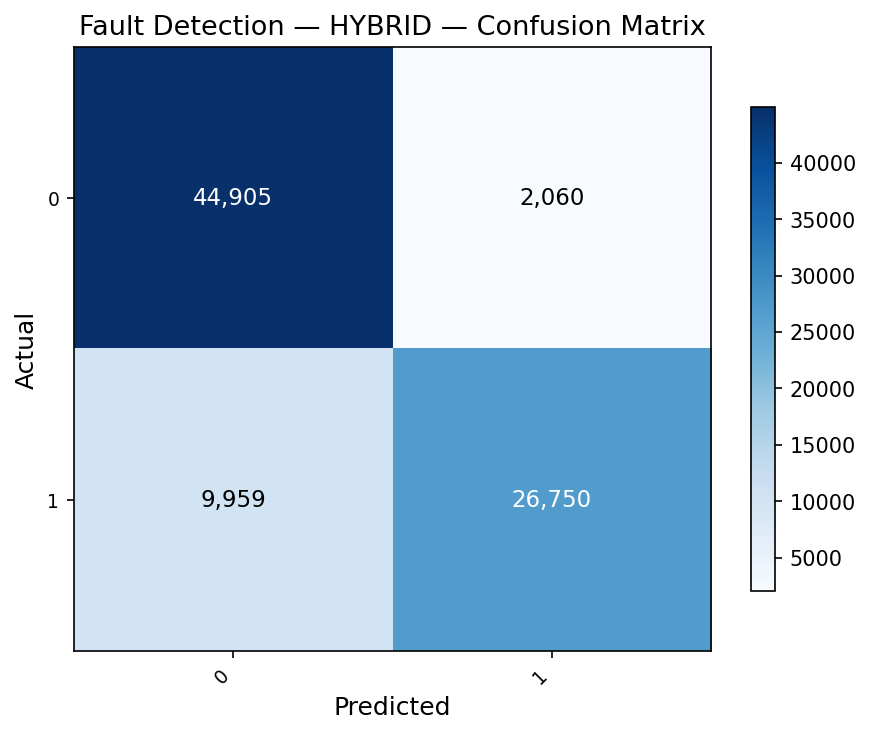


confusion_ablation_full_lstm.png


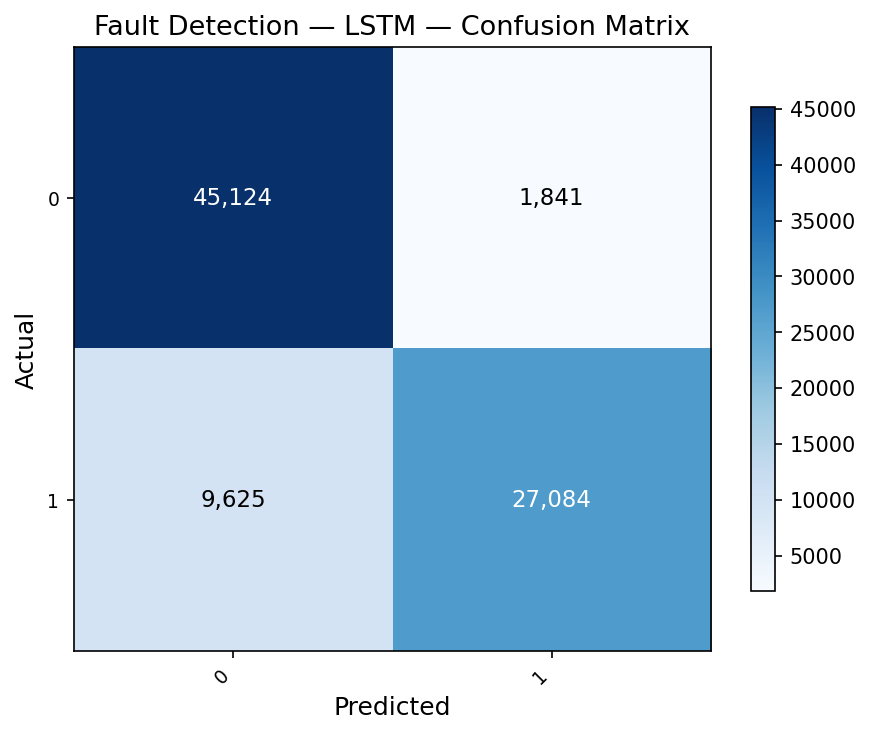


confusion_ablation_full_mlp.png


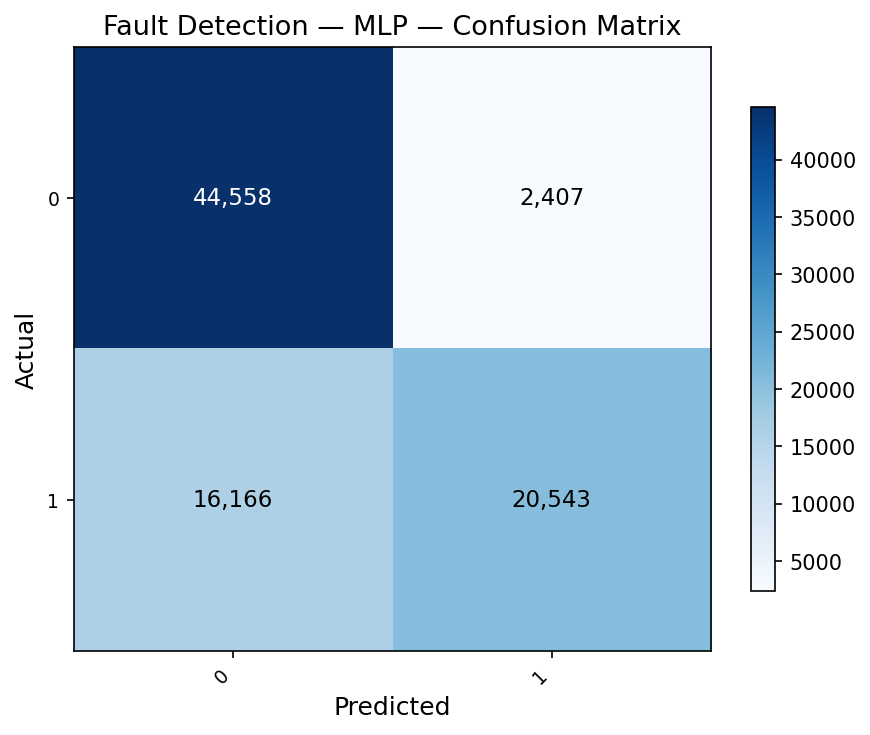


confusion_ablation_full_random_forest.png


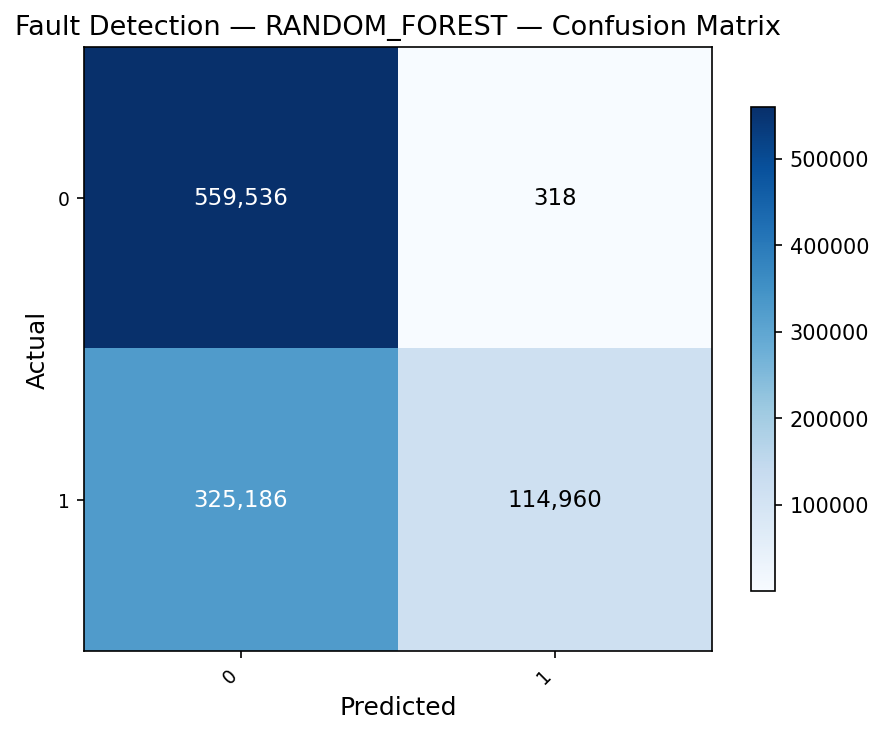


confusion_ablation_scada_only_hybrid.png


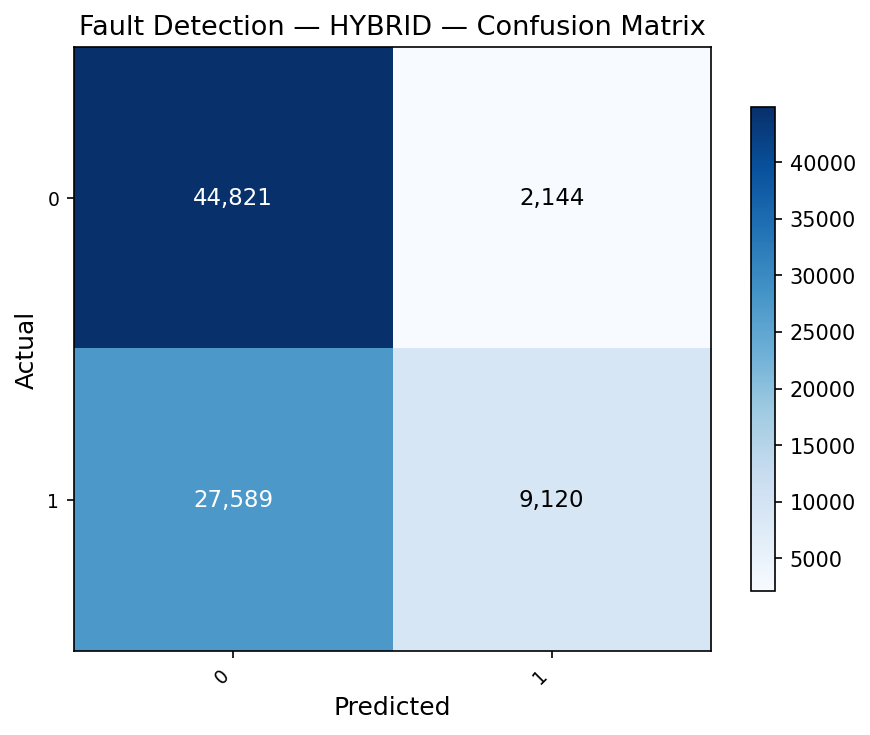


confusion_ablation_scada_only_lstm.png


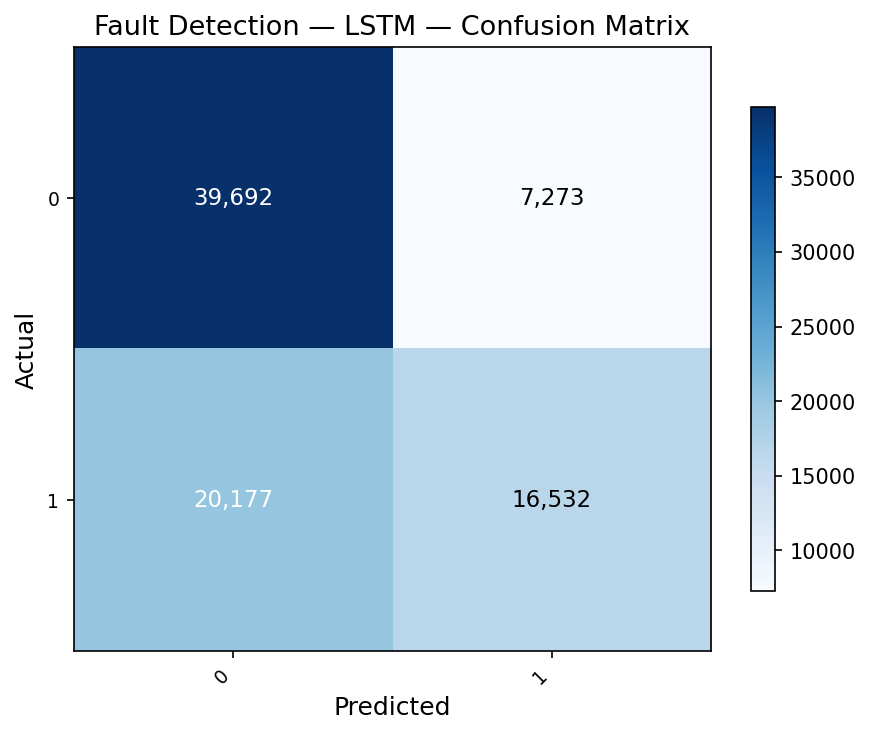


confusion_ablation_scada_only_mlp.png


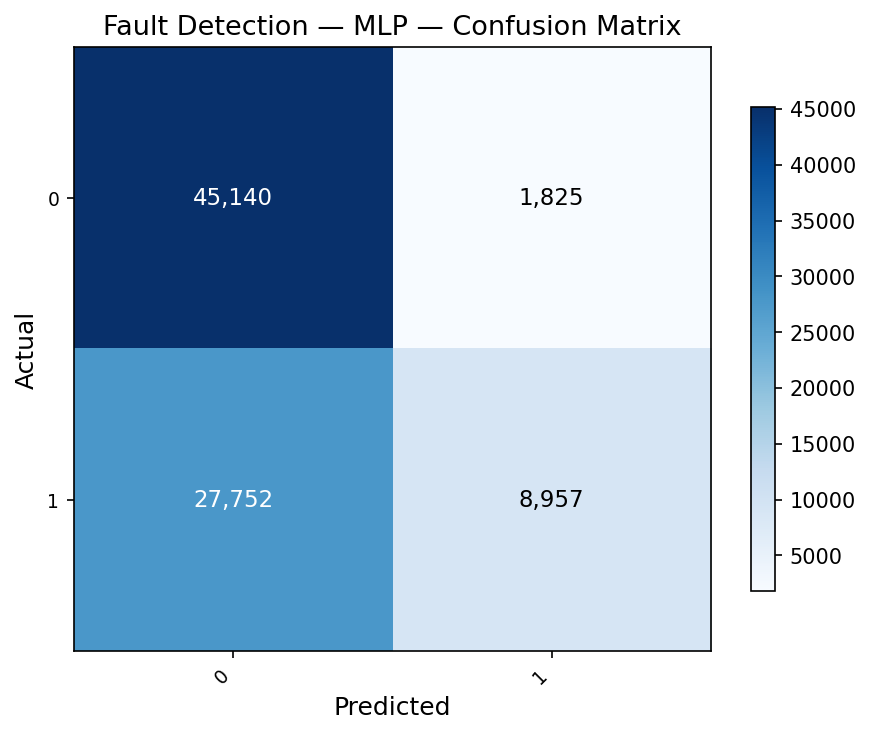


confusion_ablation_scada_only_random_forest.png


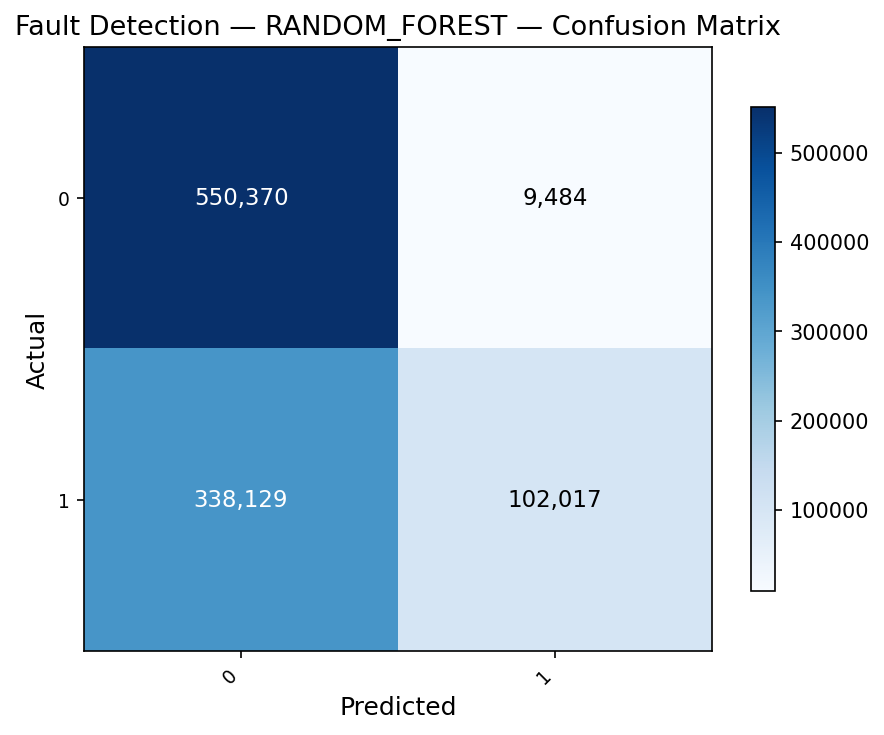

In [8]:
from IPython.display import Image, display as ipy_disp

# All artifacts now land in PT_DIR (outputs/sequence_models) regardless of model family.
pngs = sorted(pathlib.Path(PT_DIR).glob("*.png"))
for p in pngs[:8]:   # show first 8 to keep notebook manageable
    print(f"\n{p.name}")
    ipy_disp(Image(str(p)))


## 8. Deployment model quick test

In [9]:
# Deployment models (real-SCADA-only) — found via manifest paths.
# Look for deployment_*.pkl next to each tabular model.
for mode, pkl_path_str in model_paths.get("fault_active", {}).items():
    if pkl_path_str is None or not pkl_path_str.endswith(".pkl"):
        continue
    dep_path = pathlib.Path(pkl_path_str).parent / f"deployment_{pathlib.Path(pkl_path_str).stem.replace('model_', '', 1)}.pkl"
    if dep_path.exists():
        print(f"\nDeployment {mode.upper()} (real-SCADA-only):")
        try:
            auc_dep, y_dep, yp_dep = eval_tabular_model(dep_path, test_entries, "detection")
            results_summary[f"{mode.upper()} Deployment Detection AUC"] = auc_dep
            print(f"  Deployment AUC: {auc_dep:.4f}  (works on real SCADA data — no IV-curve or stress signals)")
        except Exception as ex:
            print(f"  (skipped: {ex})")
    else:
        print(f"  [{mode}] Deployment model not found at {dep_path} — run notebook 02 first.")



Deployment RANDOM_FOREST (real-SCADA-only):
After daytime filter: 307,611 rows
After daytime filter: 308,092 rows
After daytime filter: 307,730 rows
After daytime filter: 306,893 rows
After daytime filter: 307,731 rows
After daytime filter: 307,362 rows
After daytime filter: 304,076 rows
After daytime filter: 306,872 rows
After daytime filter: 306,362 rows
After daytime filter: 303,910 rows
  Stratified subsample (by fault_type) → 1,000,000 rows
  load_split: shrank buffer to 1,000,000 rows after 10/79 entries
After daytime filter: 305,312 rows
After daytime filter: 306,643 rows
After daytime filter: 306,438 rows
After daytime filter: 302,403 rows
After daytime filter: 306,472 rows
After daytime filter: 305,936 rows
After daytime filter: 306,525 rows
  Stratified subsample (by fault_type) → 1,000,000 rows
  load_split: shrank buffer to 1,000,000 rows after 17/79 entries
After daytime filter: 306,950 rows
After daytime filter: 298,935 rows
After daytime filter: 302,316 rows
After dayti

## 9. Save final report

In [10]:
lines = [
    "SOLEY ML — Model Comparison Report",
    "=" * 50, "",
    f"Data directory:  {_extra.get('data_dir', '(unknown)')}",
    f"Test files:      {len(test_entries)}  "
    f"({len(test_entries_cls)} with fault labels)",
    "",
    "Model                                   ROC AUC",
    "-" * 50,
]
for k, v in sorted(results_summary.items(), key=lambda x: -x[1]):
    lines.append(f"  {k:<40s}  {v:.4f}")

report_text = "\n".join(lines)
report_path = pathlib.Path(OUTPUT_DIR) / "evaluation_report.txt"
report_path.write_text(report_text, encoding="utf-8")
print(report_text)
print(f"\nSaved to {report_path}")


SOLEY ML — Model Comparison Report

Data directory:  dataset
Test files:      79  (74 with fault labels)

Model                                   ROC AUC
--------------------------------------------------
  PT HYBRID Classification AUC              0.9665
  PT LSTM Classification AUC                0.9637
  PT LSTM Detection AUC                     0.8946
  RANDOM_FOREST Classification AUC          0.8821
  PT HYBRID Detection AUC                   0.8812
  PT MLP Classification AUC                 0.8800
  PT MLP Detection AUC                      0.8208
  RANDOM_FOREST Detection AUC               0.7164
  RANDOM_FOREST Deployment Detection AUC    0.5882

Saved to outputs/evaluation/evaluation_report.txt
